In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

print("A/B Testing Notebook Started")

A/B Testing Notebook Started


In [2]:
baseline_conversion = 0.4023

print(
    f"Current Product View → Add to Cart conversion: "
    f"{baseline_conversion * 100:.2f}%"
)

Current Product View → Add to Cart conversion: 40.23%


In [3]:
np.random.seed(42)

sample_size = 20000

control_users = sample_size
treatment_users = sample_size

control_conversion = 0.4023

# Assume improved CTA increases conversion by 3 percentage points
treatment_conversion = 0.4323

control_add_to_cart = np.random.binomial(
    control_users,
    control_conversion
)

treatment_add_to_cart = np.random.binomial(
    treatment_users,
    treatment_conversion
)

print("Control Add to Cart:", control_add_to_cart)
print("Treatment Add to Cart:", treatment_add_to_cart)

Control Add to Cart: 7978
Treatment Add to Cart: 8703


In [4]:
control_rate = (
    control_add_to_cart
    / control_users
)

treatment_rate = (
    treatment_add_to_cart
    / treatment_users
)

print(
    f"Control Conversion: "
    f"{control_rate * 100:.2f}%"
)

print(
    f"Treatment Conversion: "
    f"{treatment_rate * 100:.2f}%"
)

Control Conversion: 39.89%
Treatment Conversion: 43.52%


In [5]:
absolute_lift = (
    treatment_rate
    - control_rate
)

relative_lift = (
    absolute_lift
    / control_rate
)

print(
    f"Absolute Lift: "
    f"{absolute_lift * 100:.2f} percentage points"
)

print(
    f"Relative Lift: "
    f"{relative_lift * 100:.2f}%"
)

Absolute Lift: 3.63 percentage points
Relative Lift: 9.09%


In [6]:
contingency_table = [
    [
        control_add_to_cart,
        control_users - control_add_to_cart
    ],
    [
        treatment_add_to_cart,
        treatment_users - treatment_add_to_cart
    ]
]

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 53.902029691233835
p-value: 2.1073988941955456e-13


In [7]:
alpha = 0.05

if p_value < alpha:
    print(
        "Result: Statistically significant difference."
    )
else:
    print(
        "Result: No statistically significant difference."
    )

Result: Statistically significant difference.


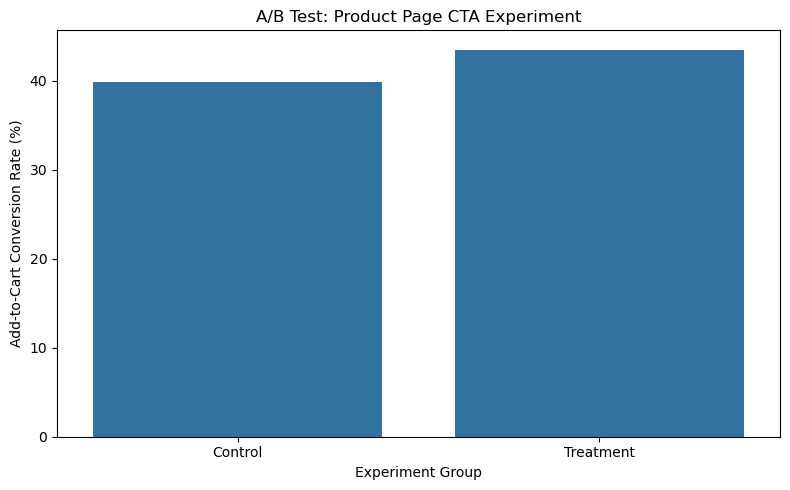

In [8]:
ab_results = pd.DataFrame({
    "Group": ["Control", "Treatment"],
    "Conversion Rate": [
        control_rate * 100,
        treatment_rate * 100
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=ab_results,
    x="Group",
    y="Conversion Rate"
)

plt.title(
    "A/B Test: Product Page CTA Experiment"
)

plt.ylabel("Add-to-Cart Conversion Rate (%)")

plt.xlabel("Experiment Group")

plt.tight_layout()

plt.show()

In [9]:
ab_summary = pd.DataFrame({
    "metric": [
        "Control conversion",
        "Treatment conversion",
        "Absolute lift",
        "Relative lift",
        "P-value",
        "Statistically significant"
    ],
    
    "value": [
        f"{control_rate * 100:.2f}%",
        f"{treatment_rate * 100:.2f}%",
        f"{absolute_lift * 100:.2f} pp",
        f"{relative_lift * 100:.2f}%",
        round(p_value, 6),
        "Yes" if p_value < alpha else "No"
    ]
})

ab_summary

,metric,value
0,Control conversion,39.89%
1,Treatment conversion,43.52%
2,Absolute lift,3.63 pp
3,Relative lift,9.09%
4,P-value,0.0
5,Statistically significant,Yes


In [10]:
ab_summary.to_csv(
    "../data/processed/ab_test_summary.csv",
    index=False
)

print("A/B test summary saved successfully!")

A/B test summary saved successfully!
